# Exploratory Data Analysis (EDA)

## Objective

The objective of this project is to explore an e-commerce sales dataset to uncover patterns, trends, relationships, and potential outliers using descriptive statistics and data visualization.

### Business Questions

- Which products generate the highest revenue?
- Which payment methods are most popular?
- Which referral sources attract the most customers?
- How do sales change over time?
- Are there unusual purchasing behaviours?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

In [2]:
import seaborn as sns
sns.set_theme()

In [3]:
df= pd.read_excel("Dataset for Data Analytics.xlsx")
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [4]:
print(df.shape)

(1200, 14)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [6]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

The dataset contains 1200 observations and 14 variables. There are no duplicate records, and the only missing values are in the couponCode column, representing customers who did not apply a coupon.

In [8]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,1200,2024-03-22 16:58:48,2023-01-01 00:00:00,2023-08-03 18:00:00,2024-03-23 00:00:00,2024-11-08 12:00:00,2025-06-30 00:00:00,NaN
Quantity,1200.0,2.945833,1.0,2.0,3.0,4.0,5.0,1.407557
UnitPrice,1200.0,356.41275,11.39,186.0625,364.21,521.57,699.93,197.177146
ItemsInCart,1200.0,5.485,1.0,4.0,5.0,7.0,10.0,2.281983
TotalPrice,1200.0,1053.9683,11.39,410.52,823.615,1578.475,3456.4,819.856558


In [9]:
df.median(numeric_only=True)

Quantity         3.000
UnitPrice      364.210
ItemsInCart      5.000
TotalPrice     823.615
dtype: float64

In [10]:
mode_summary = pd.DataFrame({
    "Mode": df.mode().iloc[0]
})
mode_summary

,Mode
OrderID,ORD200000
Date,2023-08-20 00:00:00
CustomerID,C14847
Product,Printer
Quantity,1.0
UnitPrice,127.18
ShippingAddress,533 Main St
PaymentMethod,Online
OrderStatus,Cancelled
TrackingNumber,TRK10003020


In [11]:
df.skew(numeric_only=True)

Quantity       0.027922
UnitPrice     -0.026512
ItemsInCart    0.000877
TotalPrice     0.891359
dtype: float64

In [12]:
summary = pd.DataFrame({
    "Mean": df.mean(numeric_only=True),
    "Median": df.median(numeric_only=True),
    "Std Dev": df.std(numeric_only=True),
    "Skewness": df.skew(numeric_only=True)
    })

summary

,Mean,Median,Std Dev,Skewness
Quantity,2.945833,3.000,1.407557,0.027922
UnitPrice,356.412750,364.210,197.177146,-0.026512
ItemsInCart,5.485000,5.000,2.281983,0.000877
TotalPrice,1053.968300,823.615,819.856558,0.891359


In [13]:
df.loc[df["TotalPrice"].idxmax()]


OrderID                      ORD200789
Date               2023-08-17 00:00:00
CustomerID                      C57276
Product                         Tablet
Quantity                             5
UnitPrice                       691.28
ShippingAddress            183 Main St
PaymentMethod                   Online
OrderStatus                  Delivered
TrackingNumber             TRK75899752
ItemsInCart                         10
CouponCode                      SAVE10
ReferralSource                   Email
TotalPrice                      3456.4
Name: 789, dtype: object

In [14]:
df.loc[df["TotalPrice"].idxmin()]

OrderID                      ORD201161
Date               2023-10-16 00:00:00
CustomerID                      C32570
Product                          Phone
Quantity                             1
UnitPrice                        11.39
ShippingAddress            826 Main St
PaymentMethod                     Cash
OrderStatus                  Cancelled
TrackingNumber             TRK35969968
ItemsInCart                          6
CouponCode                    WINTER15
ReferralSource                   Email
TotalPrice                       11.39
Name: 1161, dtype: object

### Interpretation
- The average order value is 1053.97, indicating that customers typically spend around this amount per transaction. 
- On average, customers purchase about 3 items per order, suggesting that most transactions involve only a few items. 
- The highest purchase recorded was 3456.40, which is a bulk order of tablets, while the lowest purchase of 11.39 reflects low-value transactions involving the purchase single inexpensive item.

In [15]:
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


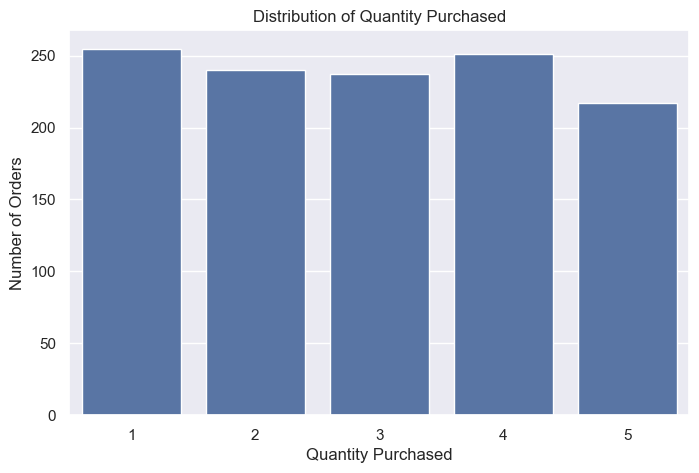

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Quantity")

plt.title("Distribution of Quantity Purchased")
plt.xlabel("Quantity Purchased")
plt.ylabel("Number of Orders")

plt.show()

In [17]:
Highest_Quantity = df["Quantity"].max()
Lowest_Quantity = df["Quantity"].min()


print("Highest Order Quantity is", Highest_Quantity) 
print("Lowest Order Quantity is", Lowest_Quantity) 

Highest Order Quantity is 5
Lowest Order Quantity is 1


In [18]:
(df["Quantity"] == 1).sum()

np.int64(255)

In [19]:
df["Quantity"].value_counts()[5]

np.int64(217)

### Distribution of Quantity Purchased

[Count Plot]

#### Interpretation


The distribution of purchase quantities is relatively uniform across values 1 to 5. Orders containing 1 item are the most common (255), while 5-item orders occur least frequently (217). However, the differences in frequency are relatively small, indicating that customers purchase varying quantities at comparable rates. No obvious skewness or unusual concentration is observed in the quantity distribution.

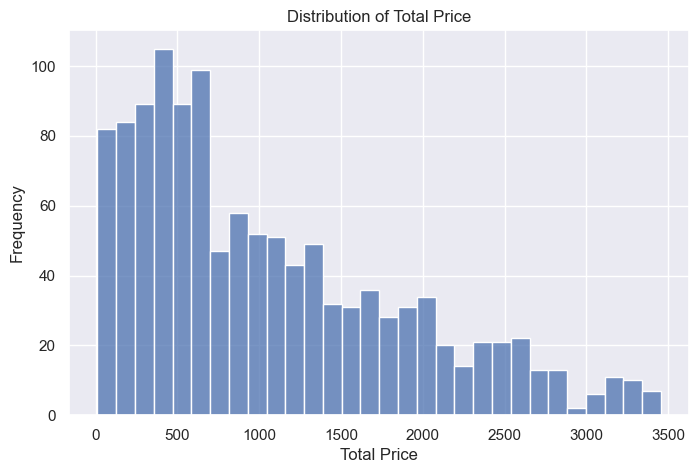

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df["TotalPrice"], bins=30)
plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.show()

In [21]:
Highest_Purchase = df["TotalPrice"].max()
Lowest_Purchase = df["TotalPrice"].min()


print("Highest Purchase is",Highest_Purchase)
print("Lowest Purchase is",Lowest_Purchase) 

Highest Purchase is 3456.4
Lowest Purchase is 11.39


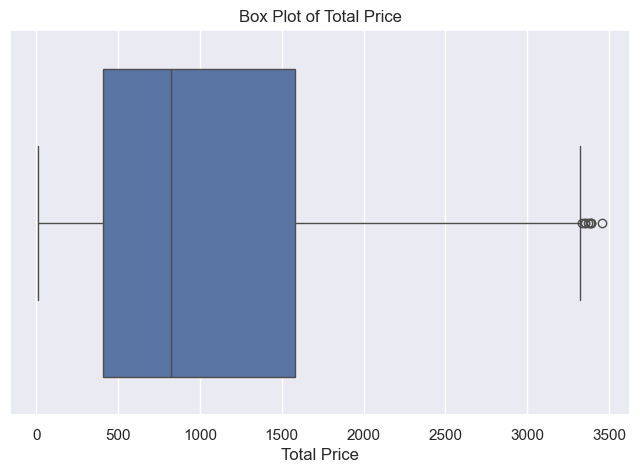

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["TotalPrice"])

plt.title("Box Plot of Total Price")
plt.xlabel("Total Price")

plt.show()

### Distribution of Total Price

[Histogram]

[Box Plot]

#### Interpretation
The Total Price distribution is positively skewed. Most transactions fall below ₦1,000, while a few high-value purchases create a long right tail. The box plot confirms this pattern and highlights several high-value outliers.

#### Business Insight
The company relies primarily on many low- to moderate-value transactions, with a small number of high-value purchases contributing disproportionately to revenue. Strategies such as upselling, product bundling, and customer loyalty programs could help increase the average order value.

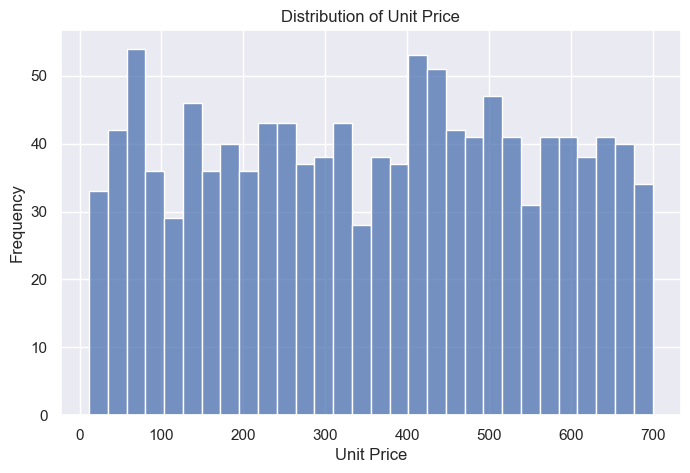

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df["UnitPrice"], bins=30)
plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()

In [23]:
df["UnitPrice"].min()

11.39

In [24]:
df["UnitPrice"].max()

699.93

 ### Distribution of Unit Price

[Histogram]

#### Interpretation

The histogram indicates that the Unit Price variable is fairly evenly distributed across the observed price range, with values spanning from $11.39
 to $699.93. No single price range dominates the distribution, suggesting that products are offered across a broad spectrum of price points. The absence of a pronounced peak or strong skewness indicates that the business maintains a relatively balanced pricing structure, catering to customers with varying purchasing budgets.

#### Business Insight

The broad distribution of unit prices suggests that the business adopts a diversified pricing strategy by offering products at multiple price points. This allows the business to appeal to a wider customer base, from budget-conscious buyers to those seeking higher-priced products. Further analysis of sales volume and revenue by price range could help identify which pricing segments contribute most to overall business performance.

In [25]:
product_counts = df["Product"].value_counts()
product_counts

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

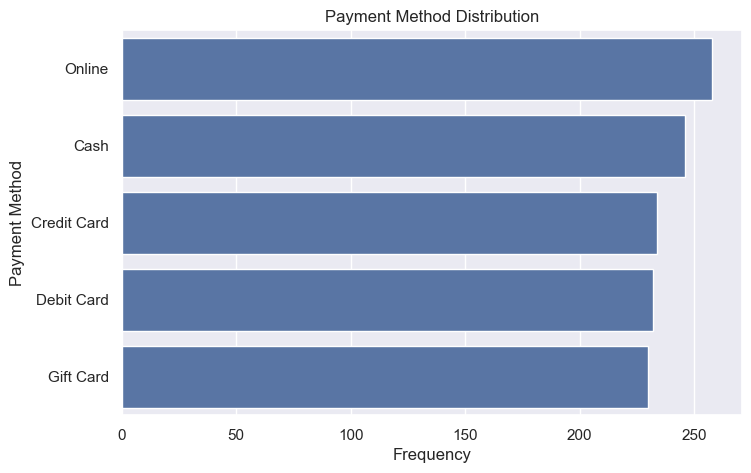

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, 
              y="PaymentMethod",
             order=df["PaymentMethod"].value_counts().index
)

plt.title("Payment Method Distribution")
plt.xlabel("Frequency")
plt.ylabel("Payment Method")

plt.show()

In [28]:
PaymentMethod_counts = df["PaymentMethod"].value_counts()
PaymentMethod_counts

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

### Payment Method Distribution

[Bar Chart]

#### Interpretation

The chart shows that **Online is the most frequently used payment method**, followed closely by Cash. Debit Card, Credit Card, and Gift Card are used at slightly lower but comparable frequencies. Overall, the distribution of payment methods is relatively balanced, indicating that customers utilize multiple payment options rather than relying heavily on a single payment method.

#### Business Insight

The balanced distribution of payment methods suggests that offering a variety of payment options effectively meets diverse customer preferences. While Online and Cash payments are used slightly more often, the relatively small differences across all payment methods indicate that maintaining support for each option is important to ensure a seamless customer experience. Monitoring payment method trends over time can also help the business optimize payment infrastructure and identify opportunities to promote more efficient or cost-effective payment channels.

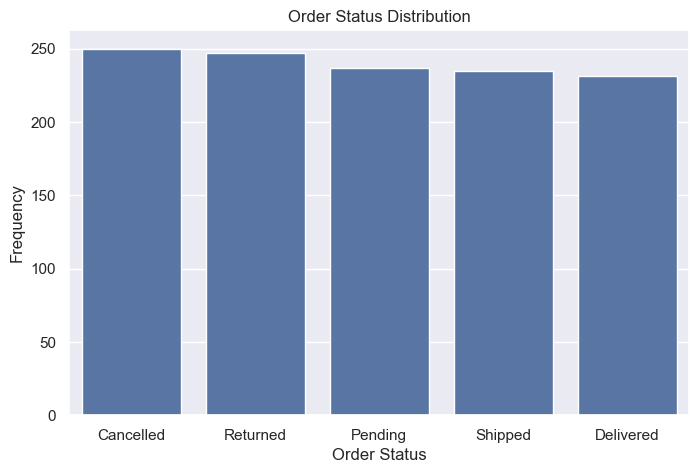

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, 
              x="OrderStatus",
             order=df["OrderStatus"].value_counts().index
             )

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Frequency")

plt.show()

In [30]:
orderstatus_counts = df["OrderStatus"].value_counts()
orderstatus_counts 

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

### Order Status Distribution

[Count Plot]

#### Interpretation

The chart shows that **Cancelled orders have the highest frequency**, closely followed by Returned orders. Delivered orders have the lowest frequency, while Pending and Shipped orders occur at comparable levels. Overall, the distribution of order statuses is relatively balanced, indicating that no single order status overwhelmingly dominates the dataset.

#### Business Insight

The relatively high frequencies of Cancelled and Returned orders may indicate opportunities to improve customer satisfaction, product quality, or order fulfillment processes. Investigating the underlying reasons for cancellations and returns could help reduce order losses and improve operational efficiency. Meanwhile, the balanced distribution across all order statuses suggests that monitoring the entire order lifecycle is important for maintaining a smooth customer experience.

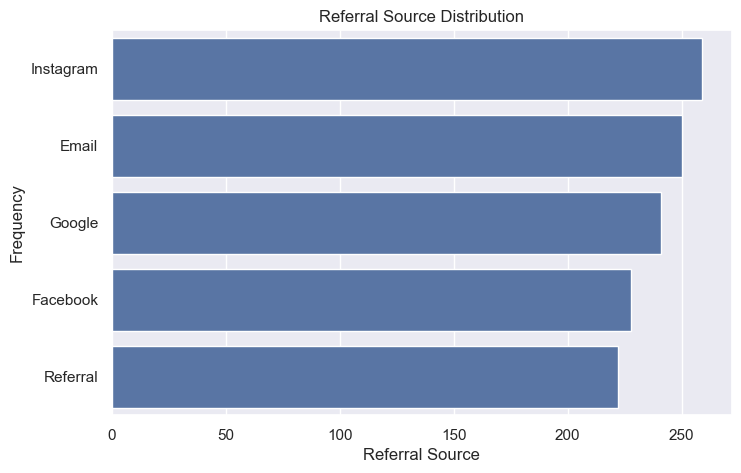

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, 
              y="ReferralSource",
             order=df["ReferralSource"].value_counts().index
             )

plt.title("Referral Source Distribution")
plt.xlabel("Referral Source")
plt.ylabel("Frequency")

plt.show()

In [32]:
ReferralSource_counts = df["ReferralSource"].value_counts()
ReferralSource_counts

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

### Referral Source Distribution

[Count Plot

#### Interpretation

The chart shows that **Instagram is the most common referral source**, followed closely by Email and Google. Referral records the lowest frequency, while Facebook also contributes a comparable number of customer referrals. Overall, the distribution of referral sources is relatively balanced, indicating that customers are acquired through multiple channels rather than relying heavily on a single source.

#### Business Insight

The balanced distribution of referral sources suggests that the business benefits from a diversified customer acquisition strategy. Although Instagram generates the highest number of referrals, the relatively small differences across all channels indicate that each marketing platform contributes meaningfully to customer acquisition. Monitoring the performance of each referral source alongside metrics such as conversion rate, revenue, and customer retention can help identify the most effective marketing channels and guide future marketing investments.

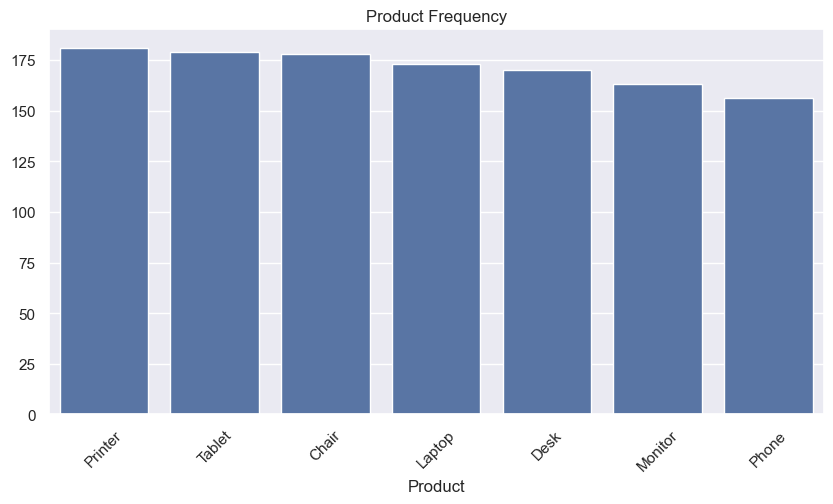

In [26]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=product_counts.index,
    y=product_counts.values
)
plt.xticks(rotation=45)
plt.title("Product Frequency")
plt.show()

### Most Purchased Products

[Bar Chart]

#### Interpretation

The chart shows that **Printer is the most frequently purchased product**, closely followed by Tablet and Chair. In contrast, **Phone records the lowest purchase frequency, although the difference compared to the other products is relatively small. Overall, the purchase frequencies are fairly balanced across all product categories, indicating that customer demand is distributed across multiple products rather than being concentrated on a single item.

#### Business Insight

The relatively balanced demand across product categories suggests that the business relies on a diversified product portfolio rather than a single best-selling product. While Printer, Tablet, and Chair should be prioritized for inventory planning due to their slightly higher demand, maintaining adequate stock across all product categories remains important. Since no product significantly outperforms the others, marketing and promotional efforts can focus on increasing overall sales while identifying opportunities to improve demand for lower-selling products such as Phone and Monitor.

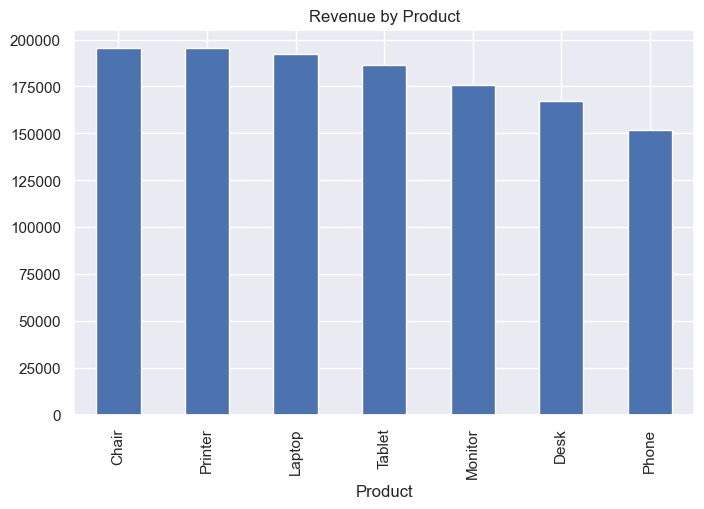

In [33]:
revenue = df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False)

revenue.plot(kind="bar", figsize=(8,5))
plt.title("Revenue by Product")
plt.show()

In [34]:
revenue

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

### Revenue by Product

[Bar Chart]

#### **Interpretation**

The chart shows that **Chair** generates the highest total revenue **(195,620.11)**, closely followed by Printer and Laptop. In contrast, **Phone** contributes the lowest revenue among the product categories **(151,722.39)**. Although revenue varies across products, the differences are relatively moderate, indicating that multiple products contribute meaningfully to overall revenue.

#### **Business Insight**

**Chair, Printer, and Laptop** are key revenue contributors and should be prioritized in inventory planning and marketing efforts. The strong revenue performance of **Chair** is particularly notable because its purchase frequency is not substantially higher than that of other products, suggesting that its revenue performance may be influenced by factors such as **higher unit prices or quantities purchased per order**. Meanwhile, **Phone** has both relatively low purchase frequency and the lowest revenue contribution, making it a potential area for further investigation. Comparing **revenue, purchase frequency, unit price, and quantity purchased** can help identify the factors driving product performance and inform pricing, promotional, and inventory decisions.


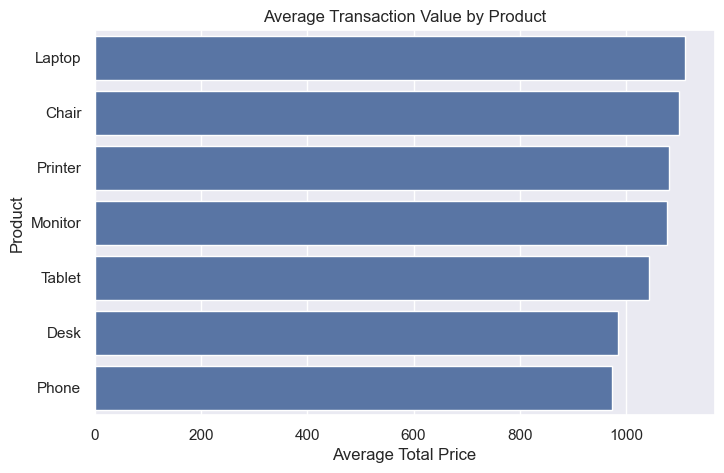

In [54]:
product_avg_value = (
    df.groupby("Product")["TotalPrice"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=product_avg_value.values,
    y=product_avg_value.index
)

plt.title("Average Transaction Value by Product")
plt.xlabel("Average Total Price")
plt.ylabel("Product")

plt.show()

#### Further Analysis: Average Transaction Value by Product

To further understand product revenue performance, the average transaction value was analyzed for each product. While total revenue shows the overall contribution of each product, average transaction value indicates how much revenue is generated per transaction on average.

#### Interpretation

The analysis shows that **Laptop** has the highest average transaction value, followed closely by Chair, while Phone has the lowest. When compared with the revenue-by-product analysis, **Chair remains a strong performer in both total revenue and average transaction value**, while Laptop's relatively high average transaction value helps explain its strong revenue contribution despite not having the highest purchase frequency. This indicates that product revenue is influenced not only by how frequently a product is purchased, but also by the value generated from each transaction.

#### Business Insight

The findings suggest that **Chair and Laptop are particularly valuable products**, although they appear to contribute to revenue in slightly different ways. Chair combines strong purchase frequency with high transaction value, while Laptop generates relatively high-value transactions, making both products important for revenue-focused strategies. The business should therefore consider purchase frequency, average transaction value, unit price, and quantity together when evaluating product performance rather than relying on total revenue alone.

In [56]:
product_analysis = df.groupby("Product").agg(
    Purchase_Frequency=("Product", "count"),
    Avg_Unit_Price=("UnitPrice", "mean"),
    Avg_Quantity=("Quantity", "mean"),
    Avg_Transaction_Value=("TotalPrice", "mean"),
    Total_Revenue=("TotalPrice", "sum")
).sort_values("Total_Revenue", ascending=False)

product_analysis

,Purchase_Frequency,Avg_Unit_Price,Avg_Quantity,Avg_Transaction_Value,Total_Revenue
Product,,,,,
Chair,178,355.660281,3.157303,1098.989382,195620.11
Printer,181,351.714917,2.994475,1080.732652,195612.61
Laptop,173,357.707052,3.092486,1110.558150,192126.56
Tablet,179,367.679106,2.776536,1042.284637,186568.95
Monitor,163,358.663620,2.944785,1077.616012,175651.41
Desk,170,329.608118,2.988235,985.058412,167459.93
Phone,156,375.217564,2.634615,972.579423,151722.39


#### Further Analysis: Factors Driving Product Revenue

#### Interpretation

The combined analysis shows that product revenue is influenced by a combination of **purchase frequency, unit price, quantity purchased, and transaction value**. Chair generates the highest revenue (195,620.11), supported by the highest purchase frequency (178) and a high average transaction value(1,098.99). Printer has the highest purchase frequency (181) and the second-highest revenue (195,612.61), while Laptop records the highest average transaction value (1,110.56) and a relatively high average quantity (3.09), contributing to its strong revenue performance. In contrast, Phone has the lowest purchase frequency (156), lowest average quantity (2.63), lowest average transaction value (972.58), and lowest total revenue (151,722.39).

#### Business Insight

The results suggest that high product revenue can be driven by different combinations of purchasing frequency, price, and quantity. Chair and Printer benefit particularly from strong purchase frequency, while Laptop's performance is supported by its high average transaction value and quantity purchased. Phone's weaker performance across several metrics makes it a potential area for further investigation, particularly to understand whether its lower sales volume and transaction value are related to customer demand, pricing, or purchasing behavior. These findings can support product-specific inventory planning, pricing decisions, upselling, and promotional strategies rather than applying the same strategy to every product.

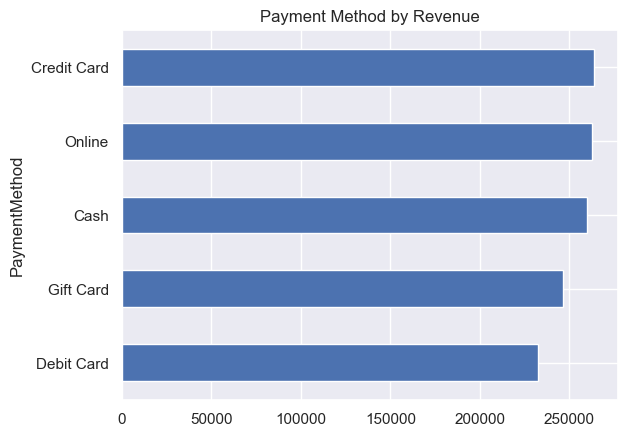

In [35]:
payment = df.groupby("PaymentMethod")["TotalPrice"].sum().sort_values()
payment.plot(kind="barh")
plt.title("Payment Method by Revenue")
plt.show()

In [36]:
payment

PaymentMethod
Debit Card     232361.18
Gift Card      246323.92
Cash           259786.29
Online         262442.94
Credit Card    263847.63
Name: TotalPrice, dtype: float64

### Revenue by Payment Method

[Bar Chart]

#### Interpretation

The chart shows that **Credit Card generates the highest total revenue (263,847.63)**, followed closely by Online and Cash payments. **Debit Card generates the lowest revenue (232,361.18)**, while Gift Card also contributes somewhat less than the other payment methods. Overall, revenue is relatively balanced across payment methods, with no single method accounting for a disproportionately large share of total revenue.

#### Business Insight

The relatively balanced revenue contribution across payment methods suggests that customers use multiple payment options to complete purchases. **Credit Card, Online, and Cash** payments are particularly important revenue-generating channels and should continue to be fully supported. The lower revenue associated with **Debit Card and Gift Card** could be investigated alongside their transaction frequencies to determine whether the difference is driven by fewer transactions or lower-value purchases. Comparing payment frequency with revenue can help the business understand customer payment preferences and optimize its payment services.

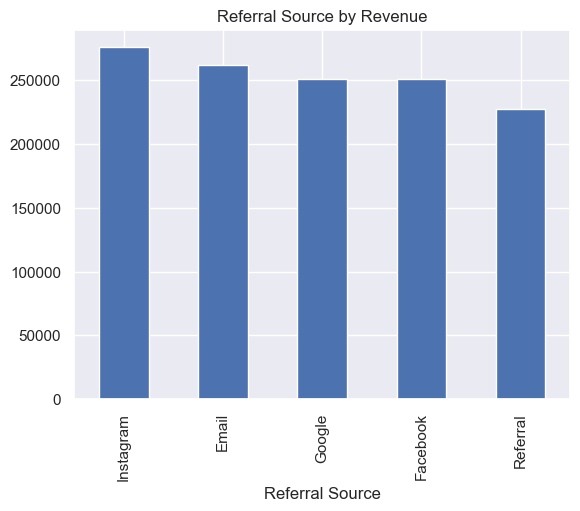

In [37]:
referral = df.groupby("ReferralSource")["TotalPrice"].sum().sort_values(ascending=False)

referral.plot(kind="bar")
plt.title("Referral Source by Revenue")
plt.xlabel("Referral Source")
plt.show()


In [40]:
referral

ReferralSource
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: TotalPrice, dtype: float64

### Revenue by Referral Source

[Bar Chart]

#### Interpretation

The chart shows that **Instagram generates the highest total revenue (275,285.45)**, followed by Email and Facebook. **Referral generates the lowest revenue (226,815.58)**, while Google contributes a similar amount to Facebook. Overall, revenue is relatively well distributed across the referral sources, although Instagram performs noticeably better than the other channels.

#### Business Insight

**Instagram** appears to be the strongest revenue-generating referral source and could be prioritized for marketing and customer acquisition efforts. However, the relatively strong performance of Email, Facebook, and Google indicates that maintaining a diversified acquisition strategy is beneficial. The lower revenue from Referral may warrant further investigation to determine whether it results from fewer customers, lower-value purchases, or lower conversion rates. Comparing referral frequency, average order value, and customer revenue across channels can help identify the most valuable sources of customers.

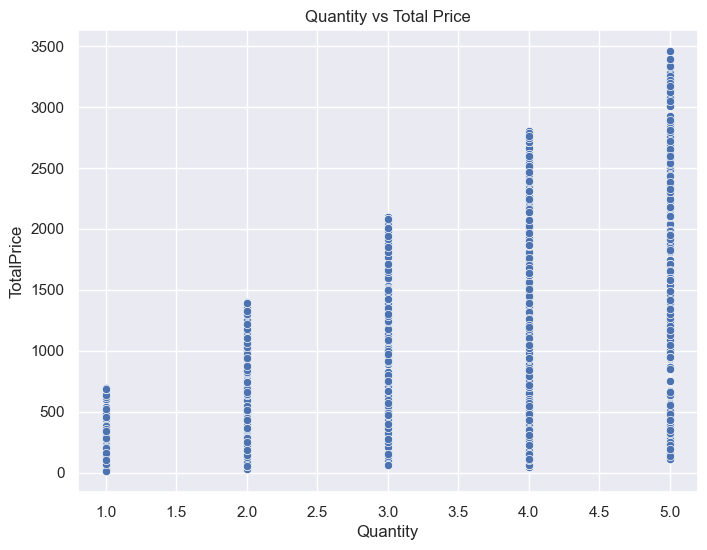

In [38]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="TotalPrice"
)

plt.title("Quantity vs Total Price")
plt.show()

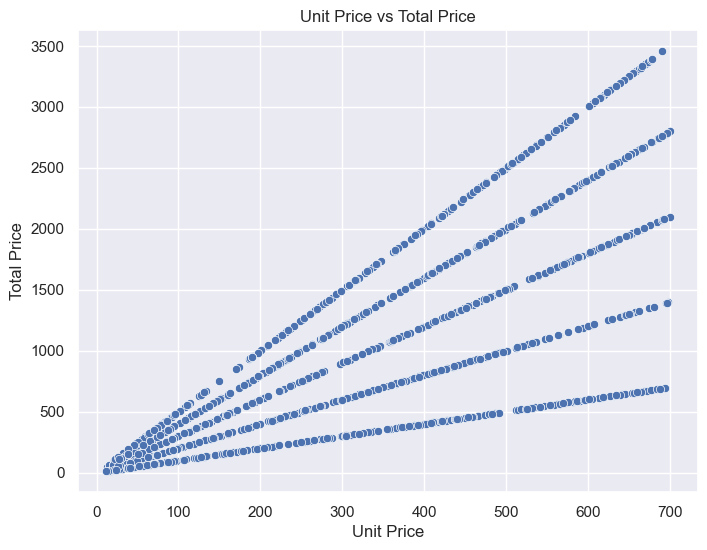

In [39]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df, x="UnitPrice", y="TotalPrice")

plt.title("Unit Price vs Total Price")
plt.xlabel("Unit Price")
plt.ylabel("Total Price")
plt.show()

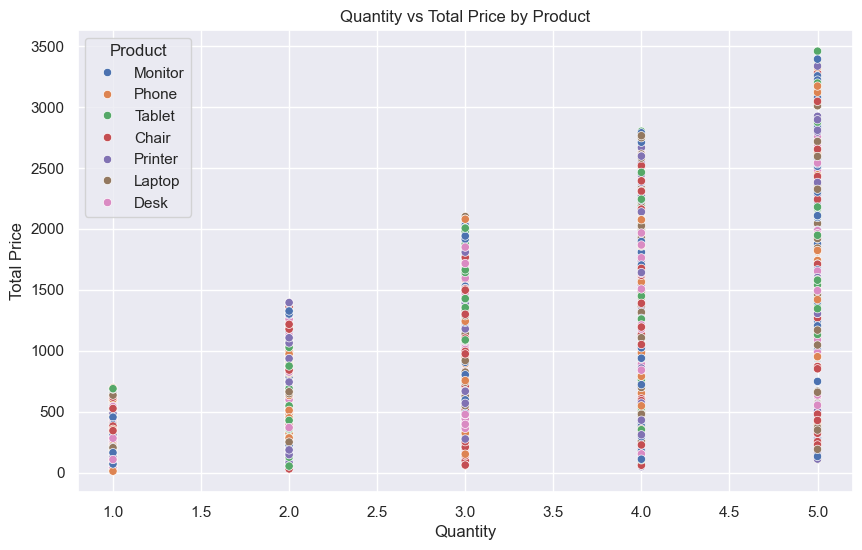

In [43]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="TotalPrice",
    hue="Product"
)

plt.title("Quantity vs Total Price by Product")
plt.xlabel("Quantity")
plt.ylabel("Total Price")
plt.legend(title="Product")
plt.show()

### Overall Relationship Analysis

[Scatter Plot]

#### Interpretation

The three visualizations collectively show that **Total Price has a strong positive relationship with both Quantity Purchased and Unit Price**. Higher quantities generally result in higher total prices, while increasing unit prices also lead to higher transaction values. The distinct patterns observed in the Unit Price vs Total Price plot and the variation across products further indicate that **Product, Unit Price, and Quantity work together to determine the final transaction value**.

#### Business Insight

The findings suggest that the business can increase transaction value through a combination of **higher-value products and larger purchase quantities**. Strategies such as product bundling, cross-selling, upselling, and quantity-based promotions could encourage customers to purchase more while maintaining attention to product pricing. Since products generate different total values at similar quantities, analyzing product-level performance alongside unit price and quantity can help the business identify its most valuable products and develop more targeted pricing, inventory, and promotional strategies.

Text(0, 0.5, 'Total Price')

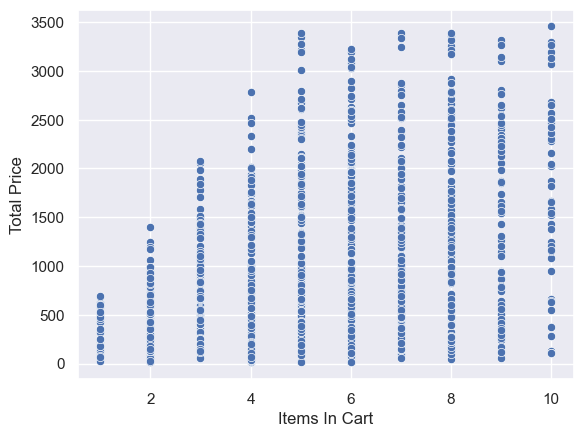

In [40]:
sns.scatterplot(
    data=df,
    x="ItemsInCart",
    y="TotalPrice")

plt.xlabel("Items In Cart")
plt.ylabel("Total Price")


### Items in Cart vs Total Price

[Scatter Plot]

#### Interpretation

The scatter plot shows a **generally positive relationship between the number of items in the cart and Total Price**. As the number of items increases, the potential Total Price also increases, with carts containing 7–10 items showing some of the highest transaction values. However, there is considerable variation in Total Price at each cart size, indicating that the number of items alone does not determine transaction value.

This finding complements the earlier relationship analyses: Quantity Purchased and Items in Cart both reflect purchasing volume, while Unit Price determines the value of each item. Therefore, transactions with a similar number of items can still have substantially different Total Prices depending on the products purchased and their unit prices.

#### Business Insight

The findings suggest that increasing the number of items customers purchase can contribute to higher transaction values, but simply increasing item count does not guarantee higher revenue because product mix and unit prices also influence Total Price. The business could use bundling, cross-selling, and personalized product recommendations to encourage customers to add more items while promoting higher-value products where appropriate. Combining Items in Cart, Quantity, Unit Price, and Product can help identify purchasing combinations that generate the greatest transaction value.

**NB: Total Price is influenced by the volume and value of items purchased. Larger quantities and cart sizes generally increase transaction value, while higher unit prices and product selection determine how much each additional item contributes to the final purchase value.**

In [41]:
df["Month"] = df["Date"].dt.month_name()

df["Weekday"] = df["Date"].dt.day_name()

In [42]:
df["Weekday"] 

0       Wednesday
1          Friday
2         Tuesday
3          Sunday
4        Thursday
          ...    
1195     Thursday
1196       Monday
1197     Thursday
1198     Thursday
1199       Sunday
Name: Weekday, Length: 1200, dtype: object

In [43]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly = df.groupby("Month")["TotalPrice"].sum()

monthly = monthly.reindex(month_order)

In [44]:
monthly

Month
January      124313.23
February     112344.78
March        123840.93
April        109186.05
May          135142.59
June         170616.13
July          85784.64
August        86343.21
September     69321.65
October       89834.82
November      75493.43
December      82540.50
Name: TotalPrice, dtype: float64

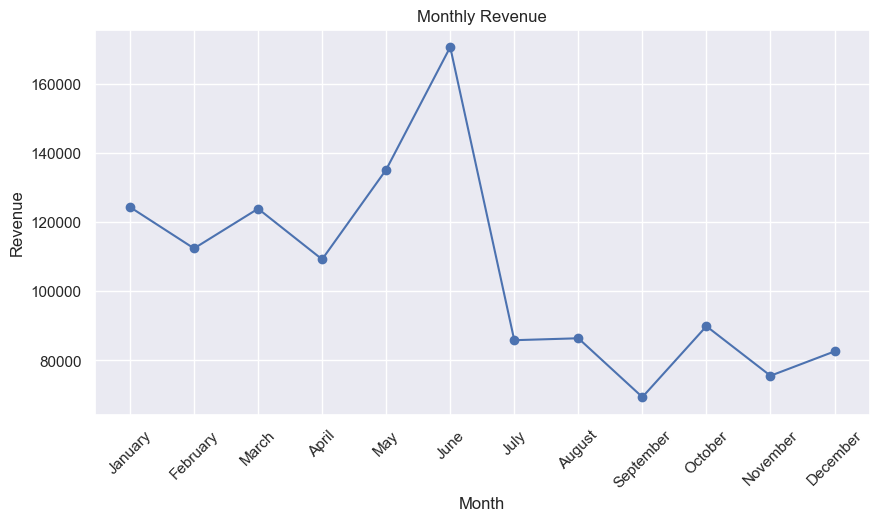

In [45]:
monthly.plot(marker="o", figsize=(10,5))

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(range(len(monthly.index)), monthly.index, rotation=45)

plt.show()

### Monthly Revenue

[Line Chart]

#### Interpretation

The chart shows noticeable fluctuations in monthly revenue throughout the year. Revenue increases from **April through June**, reaching its **highest point in June**, before dropping sharply in July. Revenue remains relatively lower during the second half of the year, with **September recording the lowest revenue**, followed by a modest recovery in October before declining again in November and increasing slightly in December.

#### Business Insight

The strong revenue performance in May and June suggests a period of particularly high sales activity, while the sharp decline after June indicates a need to investigate factors that may have contributed to the reduction in revenue. The lower revenue levels in the second half of the year may present an opportunity for targeted promotions, seasonal campaigns, or other strategies to stimulate demand during weaker periods. Comparing monthly revenue with product sales, quantity purchased, unit prices, and order status could help identify the factors driving these seasonal fluctuations.

Text(0.5, 1.0, 'Orders by Weekday')

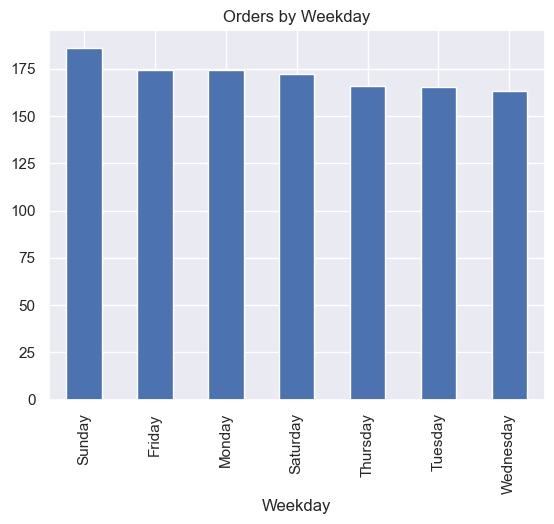

In [46]:
weekday = df["Weekday"].value_counts()

weekday.plot(kind="bar")

plt.title("Orders by Weekday")

### Orders by Weekday

[Bar Chart]

#### Interpretation

The chart shows that **Sunday records the highest number of orders***, followed by Friday and Monday. **Wednesday has the lowest order frequency**, while the remaining weekdays have relatively similar order volumes. Overall, the differences are relatively small, indicating that **orders are fairly evenly distributed throughout the week**.

#### Business Insight

The relatively balanced order volume across weekdays suggests that customer demand is not heavily concentrated on a particular day. Although Sunday records slightly higher activity, the business should maintain consistent inventory, staffing, and operational capacity throughout the week. The slightly higher Sunday demand could also provide an opportunity for targeted weekend promotions or campaigns to maximize sales.

In [49]:
type(corr)

pandas.core.frame.DataFrame

In [50]:
print(corr)

             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity     1.000000   0.014553     0.650061    0.615251
UnitPrice    0.014553   1.000000     0.000602    0.717081
ItemsInCart  0.650061   0.000602     1.000000    0.392540
TotalPrice   0.615251   0.717081     0.392540    1.000000


In [51]:
corr = df.corr(numeric_only=True)
corr

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


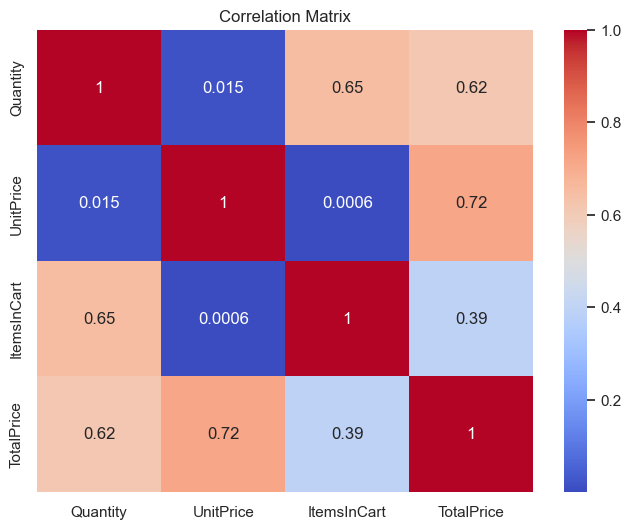

In [52]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

### Correlation Matrix 

[Heat Map]

#### Interpretation

The matrix shows that **TotalPrice has the strongest positive correlation with UnitPrice (0.72)**, followed by Quantity (0.62) and ItemsInCart (0.39). This indicates that higher unit prices and larger quantities are generally associated with higher transaction values, with UnitPrice having the strongest linear relationship with TotalPrice among the variables examined.

There is also a **relatively strong positive correlation between Quantity and ItemsInCart (0.65)**, suggesting that transactions involving more items in the cart tend to be associated with larger quantities purchased. In contrast, **UnitPrice has almost no correlation with Quantity (0.015) or ItemsInCart (0.0006)**, indicating that product pricing does not appear to be strongly associated with how much customers purchase or how many items they add to their carts.

#### Business Insight

The results reinforce the earlier scatter-plot findings that transaction value is primarily influenced by UnitPrice and Quantity, while ItemsInCart has a weaker but still positive relationship with TotalPrice. This suggests that strategies focused on higher-value products and encouraging larger purchases could increase transaction value. However, because correlation does not establish causation, these relationships should be interpreted as associations rather than proof that changing one variable will directly cause changes in another.

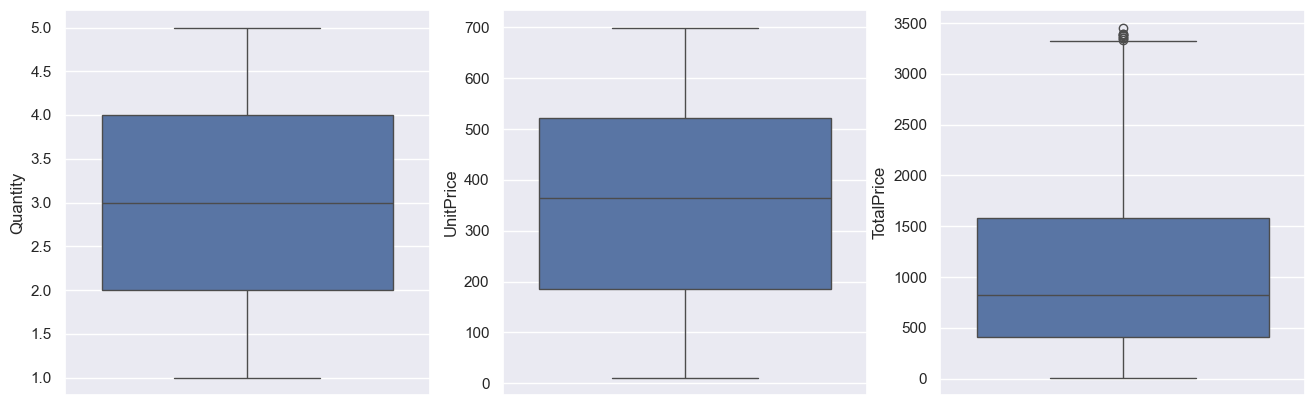

In [53]:
fig, ax = plt.subplots(1,3, figsize=(16,5))

sns.boxplot(y=df["Quantity"], ax=ax[0])

sns.boxplot(y=df["UnitPrice"], ax=ax[1])

sns.boxplot(y=df["TotalPrice"], ax=ax[2])

plt.show()

### Outlier Detection

[Box Plot]

#### Interpretation

Together, the box plots show that **Quantity and UnitPrice have relatively consistent distributions with no obvious extreme outliers**, while **Total Price exhibits considerably greater variability and several high-value outliers**. This is expected because TotalPrice is influenced by both the unit price and quantity purchased, allowing certain combinations of these variables to produce much larger transaction values.

#### Business Insight

The business appears to have **relatively stable purchasing quantities and product prices, but transaction values vary considerably**. The high-value TotalPrice outliers are particularly worth investigating because they may reveal products, pricing levels, or purchasing quantities associated with exceptionally valuable transactions. This could complement your earlier correlation and scatter-plot analysis nicely.

## Conclusion

This exploratory analysis revealed key insights into customer purchasing behaviour, sales performance, marketing effectiveness, and operational trends. The findings can support better inventory planning, targeted marketing strategies, and improvements to the customer experience.

Future work could include predictive modeling, customer segmentation, demand forecasting, or recommendation systems.